# Grating Coupler -- Meep Baseline (x-z Vertical Cross-Section)

A 2D FDTD (Meep) baseline for a uniform-period, partial-etch grating coupler --
the vertical fiber-to-chip transition, not an in-plane 2-port device like every
other component in this toolkit. This notebook simulates the **x-z (propagation,
vertical) cross-section** with the real vertical layer stack, and separately
exports the **x-y (top-down) GDS layout** from gdsfactory -- two different
projections of the same design, built independently (see Section 1 for why they
cannot share one geometry pipeline the way every other component does).

1. **Why this notebook departs from the toolkit's x-y convention.**
2. **Component definition** -- global parameters.
3. **Layer stack and grating geometry (x-z)**.
4. **Geometry visualization** -- permittivity map before paying for any FDTD run.
5. **2D Meep FDTD simulation (x-z)** -- source/monitors, field visualization.
6. **Etch-depth x duty-cycle sweep** -- coupling-efficiency search (36-point grid).
7. **Coupling efficiency** -- fiber-mode overlap integral, re-run at the promoted design.
8. **Sanity checks** -- passivity (required) and an energy budget (informative).
9. **Save artifact**.
10. **(Phase 2 stretch goal)** SAX model stub.
11. **(Bonus) Reverse-direction check** -- fiber into waveguide, a reciprocity investigation.
12. **GDS export** -- the x-y top-down layout, placed LAST (not early like every other
    component's own notebook) because it must wait until Section 6's sweep has found
    the period/duty-cycle to actually export.

**Do not use "Run All."** Work through the notebook step by step, and stop at the
marked checkpoints to actually look at the plots before continuing. FDTD runs in
this notebook take on the order of a minute each; the sweep in Section 6 runs
36 of them back to back.


## 1. Why this notebook departs from the toolkit's x-y convention

Every other component in this toolkit simulates the **x-y (propagation, in-plane
transverse)** cross-section with a 2D *effective* index (`core_index=2.7`) that
collapses the vertical (z) confinement into a single number. That is a good
approximation for an in-plane 2-port device, but a grating coupler's entire
purpose -- coupling a horizontally-guided mode to a **vertically radiating** beam
-- depends on exactly the dimension that convention throws away: BOX thickness,
Si device-layer thickness, and partial-etch grating depth.

This notebook instead simulates the **x-z (propagation, vertical) cross-section**
with the real vertical layer stack and REAL bulk indices (`core_index=3.45` for
Si, not the toolkit's effective 2.7). Concretely, Meep's own computational
`(x, y)` are used as physical `(x, z)` here -- so every plot's "y (um)" axis
below is relabeled to "z (um)" (vertical), and Meep's own invariant/extrusion
axis (always internally called "z") represents physical **y**, the real in-plane
lateral direction this 2D cross-section assumes the device is uniform along.

Two consequences worth internalizing before running anything:

- **A width taper is invisible to this simulation.** A taper only changes the
  device's extent in y, which this cross-section doesn't model at all. So the
  `coupling_efficiency` computed below is a **y-invariant idealization**
  (as if the aperture were infinitely wide/uniform in y) -- good for tuning
  period / duty-cycle / etch-depth / fiber-angle (genuinely x-z-plane physics),
  but it does not capture the real device's taper adiabaticity loss or
  finite-aperture-width mismatch in y. Same "documented Phase-1 simplification,
  not an oversight" status as the rest of the toolkit's own approximations.
- **There is no `build_geometry_from_gds()` here.** Every other component
  builds one gdsfactory `Component` and feeds it into both Meep and the GDS
  export. A GDS layer only encodes an x-y footprint -- it cannot represent a
  z-stack -- so this module's x-z FDTD geometry (`grating_coupler.py`) and its
  x-y GDS layout (`grating_coupler_gds.py`, deliberately meep-free) are two
  SEPARATE projections of the same design parameters, built independently.
  Section 12 makes this explicit again at the point where it matters.

See `grating_coupler.py`'s own module docstring for the full detail, including
an empirically-measured TE/TM gotcha specific to this rotated-axis convention
(Section 5.2 below).

In [1]:
# pic_toolkit was installed with `pip install -e .` into the `mp` conda environment,
# so it imports directly -- no sys.path manipulation needed.
import inspect
import json

import numpy as np
import matplotlib.pyplot as plt

from pic_toolkit.meep_sim import grating_coupler as gc
from pic_toolkit.meep_sim import grating_coupler_gds as gcg
from pic_toolkit import viz, style, sweep as sweep_mod

style.apply_style()
%matplotlib inline

## 2. Component definition -- Global Parameters

`grating_coupler.DEFAULT_PARAMS` starts from `pic_toolkit.params.GLOBAL_PARAMS`
(same as every other component) and overrides/adds only what this device's
physics genuinely requires -- see `grating_coupler.py`'s own inline comments for
the rationale behind each value.

In [2]:
params = dict(gc.DEFAULT_PARAMS)

print("Inherited from GLOBAL_PARAMS (unchanged):")
print(f"  wg_width_um={params['wg_width_um']}, polarization={params['polarization']}, "
      f"wl_min_um={params['wl_min_um']}, wl_max_um={params['wl_max_um']} (O-band), "
      f"dpml_um={params['dpml_um']}")

print("\nOverridden -- real (not effective) indices, finer resolution:")
print(f"  core_index={params['core_index']} (bulk Si), clad_index={params['clad_index']} (SiO2), "
      f"substrate_index={params['substrate_index']}")
print(f"  resolution={params['resolution']} px/um (GLOBAL_PARAMS' 20 cannot resolve sub-micron teeth)")

print("\nNew -- vertical layer stack (generic MPW-typical SOI values):")
print(f"  si_thickness_um={params['si_thickness_um']}, box_thickness_um={params['box_thickness_um']}, "
      f"clad_thickness_um={params['clad_thickness_um']}, etch_depth_um={params['etch_depth_um']}")

print("\nNew -- grating geometry:")
print(f"  duty_cycle={params['duty_cycle']}, n_periods={params['n_periods']}, "
      f"fiber_angle_deg={params['fiber_angle_deg']}, fiber_mfd_um={params['fiber_mfd_um']}")

Inherited from GLOBAL_PARAMS (unchanged):
  wg_width_um=0.5, polarization=TE, wl_min_um=1.3, wl_max_um=1.4 (O-band), dpml_um=1.0

Overridden -- real (not effective) indices, finer resolution:
  core_index=3.45 (bulk Si), clad_index=1.44 (SiO2), substrate_index=3.45
  resolution=40 px/um (GLOBAL_PARAMS' 20 cannot resolve sub-micron teeth)

New -- vertical layer stack (generic MPW-typical SOI values):
  si_thickness_um=0.22, box_thickness_um=2.0, clad_thickness_um=2.0, etch_depth_um=0.14

New -- grating geometry:
  duty_cycle=0.4, n_periods=22, fiber_angle_deg=10.0, fiber_mfd_um=9.2


## 3. Layer stack and grating geometry (x-z)

`derive_grating_period()` gives a first-order phase-matching estimate for the
period, seeded from the MEASURED (not guessed) effective index of the unetched
220nm Si slab's fundamental physically-TE mode at the O-band center -- see
`grating_coupler.py`'s `DEFAULT_PARAMS["n_eff_grating_guess"]` comment. The real,
partially-etched grating region's average index is somewhat lower, so this is a
starting point, not a validated value; Section 6's sweep explores duty-cycle
and etch-depth around it (not the period itself -- see that section's own note
on why the period may still need a follow-up fine-sweep).

`derive_domain()` is the single source of truth for every x/z position (grating
extent, layer boundaries, monitor planes) -- shared by `build_geometry`,
`get_permittivity_map`, and the simulation setup, so all three always agree.

**Grating period -- first-order phase-matching estimate:**

$$
\Lambda = \frac{\lambda_c}{n_{eff} - n_{clad} \sin\theta_{fiber}}
$$

- $\Lambda$ -- grating period (`period_um`)
- $\lambda_c$ -- O-band center wavelength, $(\lambda_{min}+\lambda_{max})/2$
- $n_{eff}$ -- measured effective index of the unetched 220nm Si slab's
  fundamental physically-TE mode (`n_eff_grating_guess`)
- $n_{clad}$ -- top-cladding index (`clad_index`)
- $\theta_{fiber}$ -- fiber tilt from vertical (`fiber_angle_deg`)

This is a starting estimate seeded from the *unetched* slab's index; the real
partially-etched grating region's average index differs, which is what
Section 6's etch-depth/duty-cycle sweep explores (the period itself is held
fixed at this estimate during that sweep). See `derive_grating_period()`'s
source below.

In [3]:
print(inspect.getsource(gc.derive_grating_period))

def derive_grating_period(params: dict) -> float:
    """First-order grating phase-matching estimate:

        period_um = wl_center_um / (n_eff_guess - clad_index * sin(fiber_angle))

    `n_eff_guess` defaults to the MEASURED unetched-slab n_eff (see
    DEFAULT_PARAMS["n_eff_grating_guess"]'s comment) -- a starting point only,
    refined by the notebook's own empirical etch_depth_um x duty_cycle sweep
    (the real, partially-etched grating region's average index differs from
    the unetched slab this estimate is seeded from)."""
    wl_center_um = (params["wl_min_um"] + params["wl_max_um"]) / 2
    theta = np.radians(params["fiber_angle_deg"])
    return wl_center_um / (params["n_eff_grating_guess"] - params["clad_index"] * np.sin(theta))



In [4]:
dom = gc.derive_domain(params)
params = {**params, "period_um": dom["period_um"]}  # freeze the resolved period into params

print(f"Estimated grating period : {dom['period_um'] * 1000:.1f} nm")
print(f"Tooth / trench width     : {dom['period_um'] * params['duty_cycle'] * 1000:.1f} / "
      f"{dom['period_um'] * (1 - params['duty_cycle']) * 1000:.1f} nm")
print(f"Grating aperture length  : {dom['x_grating_span']:.2f} um (n_periods={params['n_periods']})")
print(f"Cell size (x, z)         : {dom['cell_x']:.2f} x {dom['cell_z']:.2f} um")

Estimated grating period : 509.4 nm
Tooth / trench width     : 203.8 / 305.7 nm
Grating aperture length  : 11.21 um (n_periods=22)
Cell size (x, z)         : 16.21 x 7.72 um


In [5]:
print(inspect.getsource(gc.build_geometry))

def build_geometry(params: dict) -> list:
    """Ordered mp.Block list (later blocks override earlier -- standard Meep
    compositing, same convention every other module relies on): substrate,
    BOX, then one full-thickness Si block spanning the ENTIRE cell in x (input
    lead + grating base + right-of-grating stub -- extending Si to the cell
    edges is the same "input/output access stub" simplification
    waveguide.py's build_geometry_from_gds already uses), then n_periods
    clad-filled trenches punched into the grating region only. Top cladding
    has no explicit block: `default_material=clad` in `_base_simulation_kwargs`
    fills everything above z_si_top for free.

    No `build_geometry_from_gds()` counterpart -- see module docstring."""
    dom = derive_domain(params)
    substrate = mp.Medium(index=params["substrate_index"])
    core = mp.Medium(index=params["core_index"])
    clad = mp.Medium(index=params["clad_index"])

    sub_size_z = 2 * (params["substrate_thickn

## 4. Geometry visualization (permittivity map, x-z)

No FDTD timestepping yet -- `get_permittivity_map` only calls `init_sim()`, cheap
enough to sanity-check the layer stack and grating teeth before paying for a
real run.

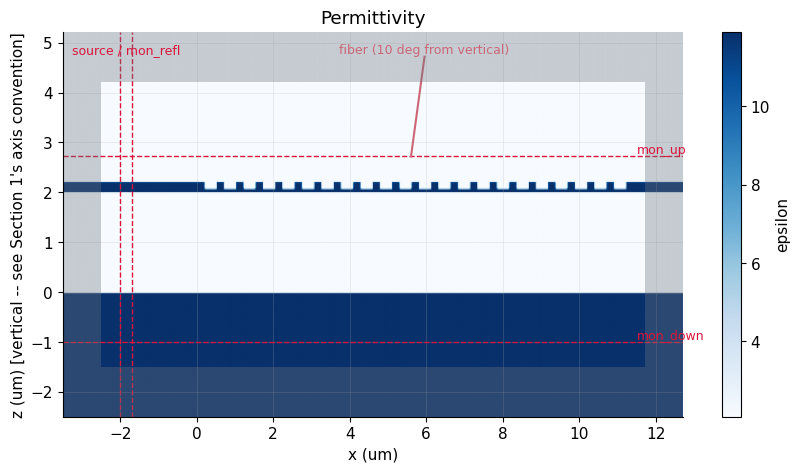

In [ ]:
permittivity = gc.get_permittivity_map(params)

fig, ax = plt.subplots(figsize=(10, 5))
viz.plot_permittivity(permittivity.eps, permittivity.extent_um, ax=ax, pml_um=params["dpml_um"])
ax.set_ylabel("z (um) [vertical -- see Section 1's axis convention]")
ax.set_aspect("auto")

# Source/monitor reference planes, drawn directly (not via viz.plot_permittivity's
# generic ports= overlay) so labels can be positioned to avoid colliding with
# each other, the title, or the colorbar -- x_src/x_refl_mon sit only 0.3um
# apart (visually coincident at this plot's ~16um x-scale), so they share ONE
# label instead of two overlapping ones; mon_up/mon_down are labeled INSIDE
# the plot's own right edge instead of past it, where the colorbar sits.
z_top = permittivity.extent_um[3]
label_z = z_top - 0.5  # headroom below the title
ax.axvline(dom["x_src"], color=style.COLOR_ANNOTATION, linestyle="--", linewidth=1)
ax.axvline(dom["x_refl_mon"], color=style.COLOR_ANNOTATION, linestyle="--", linewidth=1)
ax.annotate("source / mon_refl", ((dom["x_src"] + dom["x_refl_mon"]) / 2, label_z),
            color=style.COLOR_ANNOTATION, ha="center", va="bottom", fontsize=9, annotation_clip=False)

ax.axhline(dom["z_mon_up"], color=style.COLOR_ANNOTATION, linestyle="--", linewidth=1)
ax.annotate("mon_up", (dom["x_grating_end"] + 0.3, dom["z_mon_up"]),
            color=style.COLOR_ANNOTATION, ha="left", va="bottom", fontsize=9)
ax.axhline(dom["z_mon_down"], color=style.COLOR_ANNOTATION, linestyle="--", linewidth=1)
ax.annotate("mon_down", (dom["x_grating_end"] + 0.3, dom["z_mon_down"]),
            color=style.COLOR_ANNOTATION, ha="left", va="bottom", fontsize=9)

# Fiber tilt direction: a line from the grating aperture center at the upward
# monitor plane, stopping short of the top edge so its label has clear room
# below the "Permittivity" title (viz.plot_permittivity's ports= overlay only
# draws axis-aligned reference planes, so this tilted line is drawn directly).
theta = np.radians(params["fiber_angle_deg"])
z0 = dom["z_mon_up"]
x0 = dom["x_grating_center"]
dx = (label_z - z0) * np.tan(theta)
ax.plot([x0, x0 + dx], [z0, label_z], color=style.COLOR_ROSE, linewidth=1.5)
ax.annotate(f"fiber ({params['fiber_angle_deg']:.0f} deg from vertical)",
            (x0 + dx, label_z), color=style.COLOR_ROSE, ha="center", va="bottom",
            fontsize=9, annotation_clip=False)

> **STOP -- inspect the layer stack before running any FDTD.**
>
> Confirm, from bottom to top: substrate, BOX, the thin Si device layer with
> periodic grating teeth (visible as light notches in the dark Si stripe), and
> top cladding -- in that order, at the z-positions `derive_domain` reports
> above. Confirm the PML shading (gray) doesn't overlap the grating teeth or
> either monitor plane.

## 5. 2D Meep FDTD simulation (x-z)

### 5.1 Source and monitors -- reflection / upward / downward power

The `EigenModeSource` launches the input waveguide's fundamental mode toward the
grating. Three monitors characterize where the incident power goes:

- `mon_refl` -- a mode monitor on the input lead, giving reflection back into the
  waveguide (self-normalized against this same run's own incident mode
  coefficient, same discipline as `coupler.py`/`mzi.py`).
- `mon_up` -- a flux monitor spanning the grating aperture, just above the
  (unetched) Si surface -- upward radiated power.
- `mon_down` -- a flux monitor in the substrate, below the BOX -- power radiated
  downward and lost (this Phase-1 design has no bottom reflector).

`simulate_baseline()` runs a **single** excitation (launch toward the grating).
Unlike every other component, there is no second guided port to excite from
independently -- the "other side" is free-space radiation, not a bound mode.

In [7]:
print(inspect.getsource(gc.simulate_baseline))

def simulate_baseline(params: dict | None = None, field_snapshot_wl_um: float | None = None) -> GratingCouplerResult:
    """Full baseline characterization: launch the guided mode toward the
    grating, measure reflection back into the waveguide plus upward/downward
    radiated power (self-normalized against this run's own incident mode
    coefficient, same "self-normalize against a run's own incident power"
    discipline as coupler.py/mzi.py), and compute the fiber coupling
    efficiency via `coupling_efficiency_overlap` at every analyzed
    wavelength.

    `field_snapshot_wl_um`, if given, captures `field_snapshot` at that exact
    wavelength instead of the O-band center (the default) -- useful for
    inspecting the field at a design's own peak-coupling-efficiency
    wavelength, which is not necessarily the band center (see module
    docstring / docs/simulation_settings_record.md)."""
    dom_params = {**DEFAULT_PARAMS, **(params or {})}
    resolved_period = dom_params["p

The first real FDTD run in this notebook -- expect on the order of a minute.

In [8]:
# Field-map parameters, as requested for this visualization: etch_depth_um=0.10,
# duty_cycle=0.4. Safe to carry forward in `params` -- sweep_etch_duty() (Section
# 5.3) always overrides these two keys per grid point regardless of base_params'
# own values, and the sweep's own promoted point overwrites `params` again below.
params = {**params, "etch_depth_um": 0.10, "duty_cycle": 0.4}

result = gc.simulate_baseline(params)
print(f"Run complete: {len(result.freqs)} frequencies, "
      f"{result.wavelengths_um.min():.3f}-{result.wavelengths_um.max():.3f} um")

Run complete: 41 frequencies, 1.302-1.402 um


### 5.2 Field visualization -- eig_parity=mp.TM, Ez/Hy dominant

**Rotated-axis TE/TM gotcha (empirically measured, see `grating_coupler.py`'s
module docstring and `docs/simulation_settings_record.md`):** every OTHER module
passes `eig_parity=mp.TE` explicitly, since `mp.NO_PARITY` does not select TE (see
`CLAUDE.md` Sec 5) and their invariant Meep-z axis is physical z, and standard photonics "TE"
(no vertical E component) is exactly Meep's own `Ez(Meep)=0` definition of TE.
HERE the invariant Meep-z axis is physical y instead, so standard photonics "TE"
(E along the in-plane lateral direction, i.e. along Meep's invariant axis) means
a NONZERO Meep-z component -- Meep's own definition of **TM**. Directly measured
via `Simulation.get_eigenmode()` on this exact cross-section: Meep-labelled
`mp.TM`, band 1, gives n_eff=2.91 with dominant fields Ez(Meep)/Hy(Meep)
(physically-TE); Meep-labelled `mp.TE`, band 1, gives n_eff=2.27 with dominant
fields Ey(Meep)/Hz(Meep) (physically-TM). **This module therefore passes
`eig_parity=mp.TM` everywhere** -- the opposite label from every other module,
for a physically consistent reason.

Dominant field component: Hy (Meep-frame label) = Hz (physical) -- Ez(Meep)/Hy(Meep) expected, see note above.
Polarization: physically-TE (this module's rotated x-z axis convention maps Meep's own eig_parity=mp.TM to the physically-TE mode -- see Section 5.2 above).


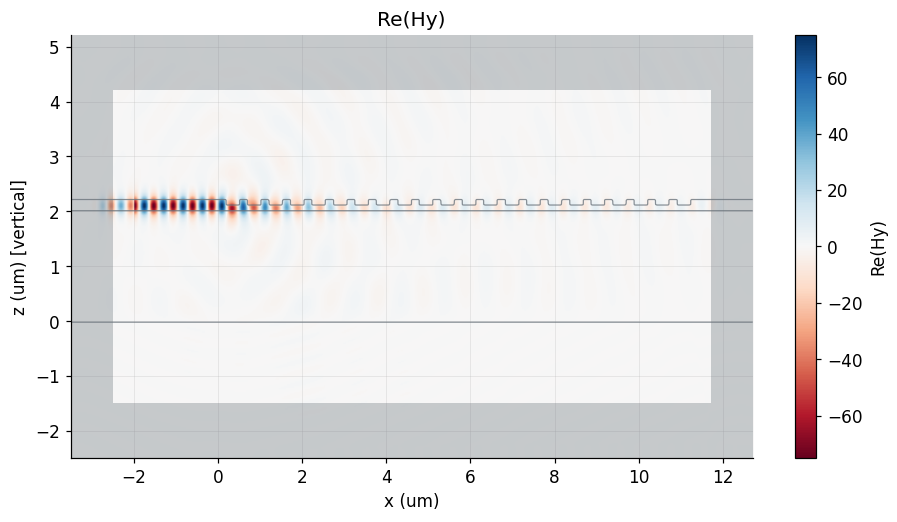

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
viz.plot_field(result.field_snapshot.field, result.field_snapshot.eps, result.field_snapshot.extent_um,
               result.field_snapshot.component, ax=ax, pml_um=params["dpml_um"])
ax.set_ylabel("z (um) [vertical]")
ax.set_aspect("auto")

# The title/label above ("Ez" or "Hy") is Meep's OWN internal axis name, not a
# physical-frame name -- under this module's rotated axis convention
# (Meep_y=physical_z, Meep_z=physical_y), Ez(Meep) is physical Ey and Hy(Meep)
# is physical Hz. Spelled out explicitly here to avoid reading "Hy" as the
# physical y-component of H (which is actually the OTHER, non-TE family here,
# and is identically zero under eig_parity=mp.TM -- Meep's own Hz(Meep), i.e.
# physical Hy, is what's forced to zero, not the reverse).
physical_name = {"Ez": "Ey (physical)", "Hy": "Hz (physical)"}[result.field_snapshot.component]
print(f"Dominant field component: {result.field_snapshot.component} (Meep-frame label) "
      f"= {physical_name} -- Ez(Meep)/Hy(Meep) expected, see note above.")
print("Polarization: physically-TE (this module's rotated x-z axis convention maps "
      "Meep's own eig_parity=mp.TM to the physically-TE mode -- see Section 5.2 above).")

> **STOP -- inspect the field before continuing.**
>
> Confirm the guided mode launches cleanly from the input lead with no visible
> standing waves before the grating, and that a visible beam radiates upward
> from the grating region at roughly the expected tilt (`fiber_angle_deg` from
> vertical).

## 6. Etch-depth x duty-cycle sweep -- coupling-efficiency search

**Not `sweep.grid_sweep()`** -- that helper's `simulate_fn`/`validate_fn`
contract is built around a pass/fail tolerance check plus a hardcoded
`pic_toolkit.sparams` 2-port artifact write, neither of which fits this
device's own result shape or objective (maximize `coupling_efficiency`, not
pass a fixed tolerance) -- same "own local infra, don't force the shared one"
precedent `coupler.py`/`mzi.py` already establish. `grating_coupler.
sweep_etch_duty()` hand-rolls the Cartesian-product loop instead, scoring each
point by both its peak AND its mean `coupling_efficiency` over the analyzed
band. `sweep.save_manifest` (a generic CSV writer, no `s_matrix` dependency)
**is** still reused for the manifest, same precedent.

**Selection metric: `coupling_efficiency_mean`, not `coupling_efficiency_max`.**
A prior pass of this sweep promoted a point purely on peak efficiency and only
afterward discovered its spectrum was sharply asymmetric -- a near-zero
response almost exactly at the O-band CENTER wavelength (where every field
snapshot in this notebook is captured) and a high plateau confined to a narrow
sub-band near the top of the analyzed range (see
`docs/simulation_settings_record.md` for the full measurement). A peak-only
metric can't distinguish that from a design that is genuinely good across the
whole O-band, so this pass promotes based on `coupling_efficiency_mean` (the
average efficiency across all analyzed wavelengths) instead --
`coupling_efficiency_max` is still recorded and mapped below as useful
context (the achievable ceiling if the band were re-centered via a period
fine-sweep), just not the selection criterion.

**The period itself is held fixed** at Section 3's phase-matching estimate for
this sweep, per the swept axes requested for this notebook (etch depth and
tooth/trench width, i.e. duty cycle). This pass uses a 36-point grid,
`etch_depth_um` in [0.08, 0.10, 0.12, 0.14, 0.16, 0.18] um x `duty_cycle` in
[0.2, 0.3, 0.4, 0.5, 0.6, 0.7], at `n_periods=22`, `resolution=40` -- each grid
point is a full FDTD run, so expect this cell to take considerably longer than
any single run above (roughly 36x a single ~1-2 minute run). The sorted
printout below and the 2D efficiency maps further down show the actual
measured optimum for this pass; see `docs/simulation_settings_record.md` for
the promoted result and any prior sweep's history.

In [10]:
print(inspect.getsource(gc.sweep_etch_duty))

def sweep_etch_duty(base_params: dict, etch_depth_values, duty_cycle_values) -> list[dict]:
    """Cartesian-product grid search over (etch_depth_um, duty_cycle). Scores
    each point by BOTH its PEAK coupling_efficiency over the analyzed band
    AND its MEAN coupling_efficiency across that same band -- a point with a
    high peak can still have a near-zero response over most of the band (a
    sharply asymmetric spectrum with the peak concentrated in a narrow
    sub-band, empirically observed for at least one promoted point -- see
    docs/simulation_settings_record.md), so `coupling_efficiency_mean` is the
    more honest "how good is this design across the WHOLE O-band" metric,
    while `coupling_efficiency_max` stays useful context (achievable ceiling,
    if the band were re-centered via a period fine-sweep). This does NOT
    reuse `pic_toolkit.sweep.grid_sweep` (its `simulate_fn`/`validate_fn`
    contract is built around a pass/fail check plus a hardcoded
    `pic_toolkit.

In [11]:
ETCH_DEPTH_SWEEP_UM = [0.08, 0.10, 0.12, 0.14, 0.16, 0.18]
DUTY_CYCLE_SWEEP = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

sweep_rows = gc.sweep_etch_duty(params, ETCH_DEPTH_SWEEP_UM, DUTY_CYCLE_SWEEP)
for row in sorted(sweep_rows, key=lambda r: -r["coupling_efficiency_mean"]):
    print(row)

[1/36] etch_depth_um=0.08, duty_cycle=0.2 ...


[2/36] etch_depth_um=0.08, duty_cycle=0.3 ...


[3/36] etch_depth_um=0.08, duty_cycle=0.4 ...


[4/36] etch_depth_um=0.08, duty_cycle=0.5 ...


[5/36] etch_depth_um=0.08, duty_cycle=0.6 ...


...

[33/36] etch_depth_um=0.18, duty_cycle=0.4 ...


[34/36] etch_depth_um=0.18, duty_cycle=0.5 ...


[35/36] etch_depth_um=0.18, duty_cycle=0.6 ...


[36/36] etch_depth_um=0.18, duty_cycle=0.7 ...


{'etch_depth_um': 0.14, 'duty_cycle': 0.4, 'coupling_efficiency_max': 0.4067504207654952, 'coupling_efficiency_argmax_wl_um': 1.3475011996983617, 'coupling_efficiency_mean': 0.28580059609047825, 'passivity_passed': True}
{'etch_depth_um': 0.16, 'duty_cycle': 0.5, 'coupling_efficiency_max': 0.42161211735777343, 'coupling_efficiency_argmax_wl_um': 1.3375978223885676, 'coupling_efficiency_mean': 0.2611325665095962, 'passivity_passed': True}
{'etch_depth_um': 0.14, 'duty_cycle': 0.3, 'coupling_efficiency_max': 0.40573867032593675, 'coupling_efficiency_argmax_wl_um': 1.3302652950730915, 'coupling_efficiency_mean': 0.2564173754968196, 'passivity_passed': True}
{'etch_depth_um': 0.12, 'duty_cycle': 0.3, 'coupling_efficiency_max': 0.4057821481802489, 'coupling_efficiency_argmax_wl_um': 1.3781111968029167, 'coupling_efficiency_mean': 0.23734915757719444, 'passivity_passed': True}
{'etch_depth_um': 0.12, 'duty_cycle': 0.2, 'coupling_efficiency_max': 0.3946247884925031, 'coupling_efficiency_argma

In [12]:
sweep_mod.save_manifest(sweep_rows, "../data/sparams/grating_coupler/sweep/etch_duty_manifest.csv")

# Selected on coupling_efficiency_mean (whole-O-band average), not
# coupling_efficiency_max -- see Section 6's markdown for why.
best = max((r for r in sweep_rows if r["passivity_passed"]), key=lambda r: r["coupling_efficiency_mean"])
print("Best point (passivity-passing, highest O-band-average efficiency):", best)

params = {**params, "etch_depth_um": best["etch_depth_um"], "duty_cycle": best["duty_cycle"]}

Best point (passivity-passing, highest O-band-average efficiency): {'etch_depth_um': 0.14, 'duty_cycle': 0.4, 'coupling_efficiency_max': 0.4067504207654952, 'coupling_efficiency_argmax_wl_um': 1.3475011996983617, 'coupling_efficiency_mean': 0.28580059609047825, 'passivity_passed': True}


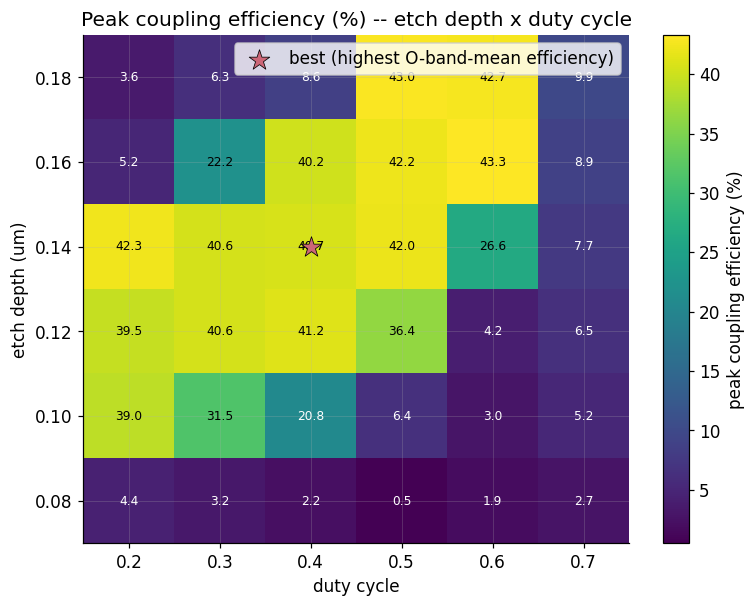

In [13]:
# 2D PEAK-coupling-efficiency map over the swept grid -- the achievable
# ceiling at each point IF the band were re-centered onto that point's own
# peak wavelength, not a measure of whole-O-band performance (see Section
# 5.3's markdown -- that distinction is exactly what motivated adding the
# MEAN-based map in the next cell, which is what `best` below is actually
# selected on). Both axes are evenly spaced, so an index-based imshow
# (relabeled ticks) avoids any half-pixel alignment ambiguity, with per-cell
# value labels since 6x6=36 points is too many to read off a bare colormap.
eff_grid_max = np.array([
    [next(r["coupling_efficiency_max"] for r in sweep_rows
          if r["etch_depth_um"] == e and r["duty_cycle"] == d) * 100
     for d in DUTY_CYCLE_SWEEP]
    for e in ETCH_DEPTH_SWEEP_UM
])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(eff_grid_max, origin="lower", aspect="auto", cmap=style.CMAP_DENSITY)
ax.set_xticks(range(len(DUTY_CYCLE_SWEEP)))
ax.set_xticklabels([f"{d:.1f}" for d in DUTY_CYCLE_SWEEP])
ax.set_yticks(range(len(ETCH_DEPTH_SWEEP_UM)))
ax.set_yticklabels([f"{e:.2f}" for e in ETCH_DEPTH_SWEEP_UM])
ax.set_xlabel("duty cycle")
ax.set_ylabel("etch depth (um)")
ax.set_title("Peak coupling efficiency (%) -- etch depth x duty cycle")
plt.colorbar(im, ax=ax, label="peak coupling efficiency (%)")

for i in range(len(ETCH_DEPTH_SWEEP_UM)):
    for j in range(len(DUTY_CYCLE_SWEEP)):
        val = eff_grid_max[i, j]
        color = "white" if val < eff_grid_max.max() * 0.5 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", color=color, fontsize=8)

best_i = ETCH_DEPTH_SWEEP_UM.index(best["etch_depth_um"])
best_j = DUTY_CYCLE_SWEEP.index(best["duty_cycle"])
ax.scatter([best_j], [best_i], marker="*", s=200, color=style.COLOR_ROSE,
           edgecolor="black", linewidth=0.5, zorder=5, label="best (highest O-band-mean efficiency)")
ax.legend(loc="upper right")

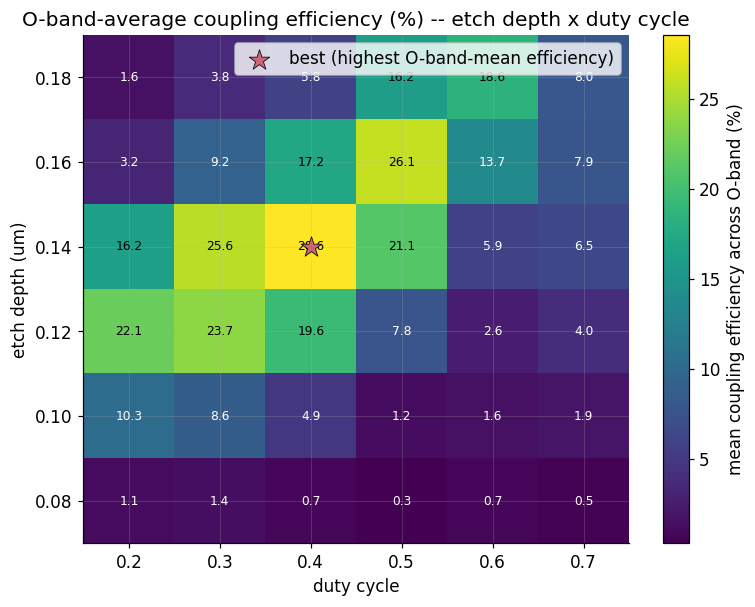

In [14]:
# 2D MEAN-coupling-efficiency map (average across the full analyzed O-band,
# 41 wavelengths per grid point) -- this is the metric `best` above is
# actually selected on, since it reflects whole-band performance rather than
# a single-wavelength peak that a narrow, sharply-detuned spectrum can also
# produce (see Section 6's markdown).
eff_grid_mean = np.array([
    [next(r["coupling_efficiency_mean"] for r in sweep_rows
          if r["etch_depth_um"] == e and r["duty_cycle"] == d) * 100
     for d in DUTY_CYCLE_SWEEP]
    for e in ETCH_DEPTH_SWEEP_UM
])

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(eff_grid_mean, origin="lower", aspect="auto", cmap=style.CMAP_DENSITY)
ax.set_xticks(range(len(DUTY_CYCLE_SWEEP)))
ax.set_xticklabels([f"{d:.1f}" for d in DUTY_CYCLE_SWEEP])
ax.set_yticks(range(len(ETCH_DEPTH_SWEEP_UM)))
ax.set_yticklabels([f"{e:.2f}" for e in ETCH_DEPTH_SWEEP_UM])
ax.set_xlabel("duty cycle")
ax.set_ylabel("etch depth (um)")
ax.set_title("O-band-average coupling efficiency (%) -- etch depth x duty cycle")
plt.colorbar(im, ax=ax, label="mean coupling efficiency across O-band (%)")

for i in range(len(ETCH_DEPTH_SWEEP_UM)):
    for j in range(len(DUTY_CYCLE_SWEEP)):
        val = eff_grid_mean[i, j]
        color = "white" if val < eff_grid_mean.max() * 0.5 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", color=color, fontsize=8)

ax.scatter([best_j], [best_i], marker="*", s=200, color=style.COLOR_ROSE,
           edgecolor="black", linewidth=0.5, zorder=5, label="best (highest O-band-mean efficiency)")
ax.legend(loc="upper right")

## 7. Coupling efficiency: fiber-mode overlap integral

Re-run the baseline at the promoted `etch_depth_um`/`duty_cycle` from the sweep
above. `coupling_efficiency` is the normalized overlap between the simulated
near-field and an assumed tilted Gaussian fiber mode -- see
`coupling_efficiency_overlap`'s own docstring for the formula and for why the
fiber's assumed lateral position is the near-field's own intensity centroid,
not the aperture's geometric center. **Reminder from Section 1: this is a
y-invariant idealization** -- it does not capture taper loss or finite-aperture
mismatch in y.

**Fiber mode -- tilted Gaussian, evaluated on the near-field monitor line:**

$$
E_{y,fiber}(x) = \exp\!\left(-\frac{[(x-x_0)\cos\theta]^2}{w_0^2}\right)
               \exp\!\left(-j k_0 \sin\theta \,(x - x_0)\right)
$$

- $w_0 = \text{MFD}/2$ (`fiber_mfd_um`/2)
- $k_0 = 2\pi n_{clad}/\lambda$
- $\theta$ -- fiber tilt from vertical (`fiber_angle_deg`)
- $x_0$ -- the simulated near-field's own intensity-weighted centroid, **not**
  the aperture's geometric center (see `coupling_efficiency_overlap`'s
  docstring for why)

The fiber's assumed tangential H field follows from the plane-wave Maxwell
relation $H=n(\hat{k}\times E)$ (Meep's own $c{=}1$ unit convention, medium
impedance $=1/n$):

$$
H_{x,fiber}(x) = -n_{clad}\cos\theta \; E_{y,fiber}(x)
$$

**Coupling efficiency -- power-normalized reciprocity (E x H) overlap, per
wavelength:**

$$
\eta(\lambda) = \frac{\left|\int\left[E_{y,sim}(x)\,H_{x,fiber}^{*}(x) + E_{y,fiber}^{*}(x)\,H_{x,sim}(x)\right]dx\right|^2}
                     {8\,P_{sim}\,P_{fiber}}
$$

$$
P_{sim} = \left|\mathrm{Re}\!\int E_{y,sim}(x)\,H_{x,sim}^{*}(x)\,dx\right|,
\qquad
P_{fiber} = \left|\mathrm{Re}\!\int E_{y,fiber}(x)\,H_{x,fiber}^{*}(x)\,dx\right|
$$

$E_{y,sim}(x)$/$H_{x,sim}(x)$ are the simulated tangential near-field's E and
H components along the monitor line at that wavelength (physical-frame; see
`coupling_efficiency_overlap()`'s "HANDEDNESS NOTE" docstring for why a raw
`Ez` DFT array needs a sign flip to become physical $E_y$ under this module's
rotated axis convention). This is the standard E x H reciprocity/mode-overlap
formula (Snyder & Love) -- properly bounded by construction, so $\eta$ can
never exceed the fraction of power actually reaching the near-field plane
(`upward_power`). It replaced an earlier, unbounded shape-only overlap that
could (and did) exceed that physical ceiling -- see
`docs/troubleshooting_log.md` for the full diagnostic story and
`docs/simulation_settings_record.md` for the corrected measurements. See
`coupling_efficiency_overlap()`'s source below for the full derivation.

In [15]:
print(inspect.getsource(gc.coupling_efficiency_overlap))

def coupling_efficiency_overlap(x_um: np.ndarray, e_sim: np.ndarray, hx_sim: np.ndarray,
                                 wl_um: float, params: dict) -> float:
    """Power-normalized reciprocity overlap between the simulated near-field
    and the fiber's assumed Gaussian mode, at one wavelength:

        eta = |integral(Ey_sim*conj(Hx_fiber) + conj(Ey_fiber)*Hx_sim dx)|^2
              / (8 * P_sim * P_fiber)

        P_sim   = |Re(integral(Ey_sim * conj(Hx_sim) dx))|
        P_fiber = |Re(integral(Ey_fiber * conj(Hx_fiber) dx))|

    This is the standard reciprocity/mode-overlap formula (Snyder & Love;
    the same formula commercial mode solvers use for waveguide/fiber
    coupling-efficiency calculations). All quantities above are in the
    PHYSICAL (x, y, z) frame, `Ey_sim = -e_sim` (see the HANDEDNESS NOTE
    below for why the minus sign is required), `Hx_sim = hx_sim` (no sign
    change -- see below), `Hx_fiber = -clad_index*cos(theta)*Ey_fiber` from
    the plane-wave/parax

Peak coupling efficiency: 40.68% at 1.3475 um


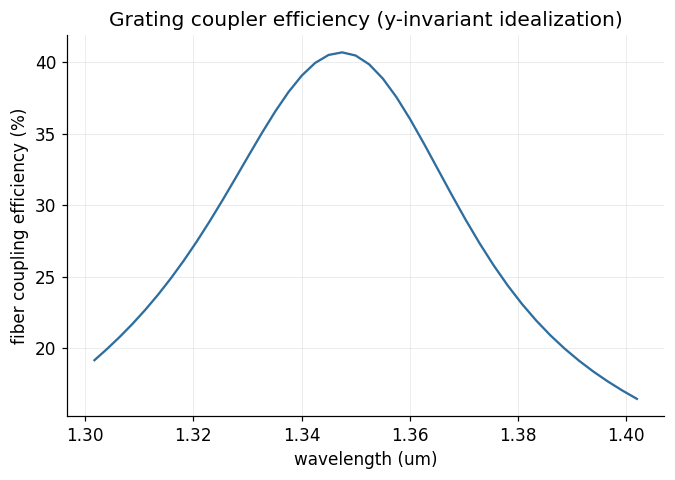

In [16]:
result = gc.simulate_baseline(params)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(result.wavelengths_um, result.coupling_efficiency * 100, color=style.COLOR_STEEL)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("fiber coupling efficiency (%)")
ax.set_title("Grating coupler efficiency (y-invariant idealization)")

peak_i = int(np.argmax(result.coupling_efficiency))
print(f"Peak coupling efficiency: {result.coupling_efficiency[peak_i] * 100:.2f}% "
      f"at {result.wavelengths_um[peak_i]:.4f} um")

Promoted design's own peak-efficiency wavelength: 1.3475 um (coupling_efficiency=40.7%)


Dominant field component: Hy (Meep-frame label) = Hz (physical).
At this wavelength -- reflection=1.2%, upward=38.3%, downward=61.8%, coupling_efficiency=40.7%


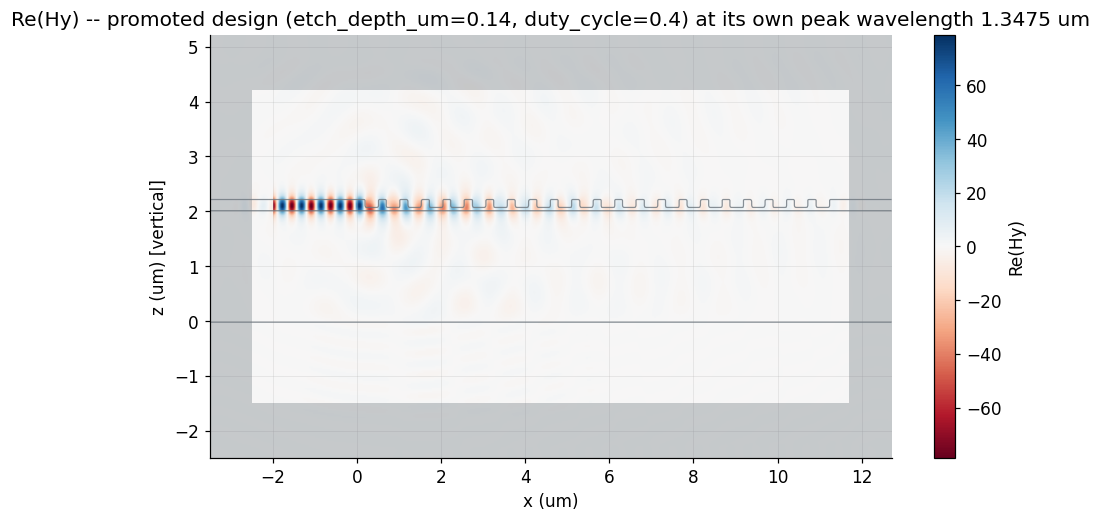

In [17]:
# Field distribution AT THE PROMOTED DESIGN'S OWN PEAK-EFFICIENCY WAVELENGTH --
# NOT the O-band center. Every field snapshot elsewhere in this notebook (and
# `simulate_baseline()`'s default) is a single-frequency DFT at fcen, which
# can land in a near-zero dip for a design whose spectrum is asymmetric (see
# Section 6's markdown and docs/simulation_settings_record.md) -- so this
# re-runs the promoted design specifically requesting the field at its own
# best wavelength, via the new `field_snapshot_wl_um` argument. `field_result`
# is a full re-run (`_run()` always computes flux/near-field alongside the
# field DFT, no partial-capture mode), but `wl_min_um`/`wl_max_um`/`n_freq`
# are unchanged, so `field_result.wavelengths_um` is the SAME 41-point grid
# as `result`'s -- `peak_i` (found from `result` above) indexes both arrays.
peak_i = int(np.argmax(result.coupling_efficiency))
peak_wl_um = float(result.wavelengths_um[peak_i])
print(f"Promoted design's own peak-efficiency wavelength: {peak_wl_um:.4f} um "
      f"(coupling_efficiency={result.coupling_efficiency[peak_i]*100:.1f}%)")

field_result = gc.simulate_baseline(params, field_snapshot_wl_um=peak_wl_um)
assert np.isclose(field_result.wavelengths_um[peak_i], peak_wl_um, atol=1e-6), \
    "wavelength grid mismatch -- field_result and result should share the same freqs"

fig, ax = plt.subplots(figsize=(10, 5))
viz.plot_field(field_result.field_snapshot.field, field_result.field_snapshot.eps,
                field_result.field_snapshot.extent_um, field_result.field_snapshot.component,
                ax=ax, pml_um=params["dpml_um"])
ax.set_ylabel("z (um) [vertical]")
ax.set_aspect("auto")
ax.set_title(f"Re({field_result.field_snapshot.component}) -- promoted design "
             f"(etch_depth_um={params['etch_depth_um']}, duty_cycle={params['duty_cycle']}) "
             f"at its own peak wavelength {peak_wl_um:.4f} um")

# Meep-frame label -> physical-frame label, same mapping as Section 5.2's note.
physical_name = {"Ez": "Ey (physical)", "Hy": "Hz (physical)"}[field_result.field_snapshot.component]
print(f"Dominant field component: {field_result.field_snapshot.component} (Meep-frame label) "
      f"= {physical_name}.")
print(f"At this wavelength -- reflection={field_result.reflection[peak_i]*100:.1f}%, "
      f"upward={field_result.upward_power[peak_i]*100:.1f}%, "
      f"downward={field_result.downward_power[peak_i]*100:.1f}%, "
      f"coupling_efficiency={field_result.coupling_efficiency[peak_i]*100:.1f}%")

## 8. Sanity checks

**Not `pic_toolkit.checks`** -- that module indexes a 2-port `s_matrix`
directly and cannot represent this device's reflection/upward/downward/
efficiency shape. `grating_coupler.py` provides its own local checks, with a
deliberate two-tier design:

- **`passivity_check`** (required, must pass): `reflection + upward + downward`
  must never exceed 1 (+ a small numerical margin) -- the fundamental
  "did the simulation do something unphysical" check.
- **`energy_budget_check`** (informative only, not a hard gate):
  `reflection + upward + downward` should not fall too far short of 1 either --
  but some shortfall here is EXPECTED (sideways leakage past the flux
  monitors' finite span, finite-aperture diffraction), not a defect, so its
  tolerance is deliberately generous.

No `reciprocity_check` -- a genuine reciprocity test needs a second, independent
run launching a tilted Gaussian beam FROM the fiber side, new source-
construction territory deferred to Phase 2.

In [18]:
print(inspect.getsource(gc.passivity_check))
print(inspect.getsource(gc.energy_budget_check))

def passivity_check(result: GratingCouplerResult, tol: float = 0.02) -> dict:
    """Primary, must-pass check: a passive device can never emit more power
    than it received. reflection + upward + downward must not exceed 1 (+
    a small numerical margin) at any wavelength -- the fundamental
    "did the simulation do something unphysical" check, same status as
    checks.passivity_check/coupler.py's own passivity_check."""
    total = result.reflection + result.upward_power + result.downward_power
    max_total = float(np.max(total))
    return {"max_total_power_fraction": max_total, "tolerance": tol, "passed": max_total < 1.0 + tol}

def energy_budget_check(result: GratingCouplerResult, max_unaccounted_fraction: float = 0.15) -> dict:
    """Secondary, INFORMATIVE check, not a hard gate: reflection + upward +
    downward should not fall too far short of 1, either -- but unlike a
    bounded 2-port/4-port device, some shortfall here is EXPECTED (sideways
    leakage past the flux m

In [19]:
checks = gc.run_all_checks(result)
print(json.dumps(checks, indent=2))
assert checks["passed"], "Baseline failed the passivity check -- do not save or use this result."
print("\nBaseline validated (passivity). Energy-budget shortfall, if any, is expected sideways/"
      "finite-aperture leakage -- see Section 8's markdown -- not a hard failure.")

{
  "passivity": {
    "max_total_power_fraction": 1.0170557313248536,
    "tolerance": 0.02,
    "passed": true
  },
  "energy_budget": {
    "min_total_power_fraction": 0.9631218912228232,
    "max_unaccounted_fraction": 0.15,
    "passed": true
  },
  "passed": true
}

Baseline validated (passivity). Energy-budget shortfall, if any, is expected sideways/finite-aperture leakage -- see Section 7's markdown -- not a hard failure.


## 9. Save artifact

Own `.npz` (numeric arrays) + `.json` (metadata) sidecar pair, via
`grating_coupler.save_artifact` -- same convention as every other component,
just not routed through `pic_toolkit.sparams` (2-port-shaped, doesn't fit this
device -- same precedent as `coupler.py`/`mzi.py`).

In [20]:
artifact_stem = "../data/sparams/grating_coupler/baseline/grating_coupler_baseline"

metadata = {
    "component": "grating_coupler",
    "geometry_params": {
        k: result.sim_params[k] for k in
        ["period_um", "duty_cycle", "n_periods", "etch_depth_um", "si_thickness_um",
         "box_thickness_um", "clad_thickness_um", "wg_width_um", "fiber_angle_deg", "fiber_mfd_um"]
    },
    "material_params": {k: result.sim_params[k] for k in ["core_index", "clad_index", "substrate_index"]},
    "polarization": f"TE (eig_parity=mp.TM in this rotated-axis convention; "
                     f"{result.field_snapshot.component} dominant -- see Section 5.2)",
    "meep_resolution": result.sim_params["resolution"],
    "simulation_params": {k: result.sim_params[k] for k in ["wl_min_um", "wl_max_um", "n_freq"]},
    "meep_version": result.sim_params["meep_version"],
    "creation_date": result.sim_params["creation_date"],
    "validation": checks,
}
gc.save_artifact(artifact_stem, result, metadata)
print(f"Saved to {artifact_stem}.npz / .json")

Saved to ../data/sparams/grating_coupler/baseline/grating_coupler_baseline.npz / .json


## 10. (Phase 2 stretch goal) SAX model

Deferred: a `data/design_points/grating_coupler.yaml` + `models/grating_coupler.py`
SAX-compatible model (roughly `insertion_loss(wl) = coupling_efficiency(wl)`
fit to a smooth curve, `S11 = sqrt(reflection(wl))`, no `S21` since this is a
fiber-to-chip transition, not a 2-port through device) is deliberately NOT
built in this notebook. Building it before `coupling_efficiency`'s shape/units
are validated against more than this one swept design point risks needing
rework -- left as a follow-up once the sweep above (and a possible period
fine-sweep, see Section 6's note) has settled on a design worth modeling.

## 11. (Bonus) Reverse-direction check -- fiber into waveguide

Everything above simulates the OUTcoupling direction only (waveguide -> grating
-> free space). As a bonus, exploratory check, this section finally builds the
piece `run_all_checks()`'s own docstring has flagged since Section 8 as
deferred: launch a tilted Gaussian beam FROM the fiber side, at this design's
own `fiber_angle_deg`, aimed down at the grating, and confirm it couples into
the waveguide's guided mode -- using `mp.GaussianBeam2DSource`, Meep's true 2D
closed-form tilted-beam source.

**This is a QUALITATIVE confirmation, not a calibrated efficiency number.**
`GaussianBeam2DSource` normalizes its amplitude via peak E-field
(`beam_E0`), not incident power the way `EigenModeSource(eig_match_freq=True)`
does for every other source in this notebook -- there is no independent
measurement of how much power this source actually launches. The reported
`guided_mode_power_relative` is therefore a relative/trend signal only (never
a percentage), read from the same `mon_refl` monitor Section 5 already uses,
now measuring the mode traveling in -x (out through the input lead) instead of
+x.

**Fiber position is deliberately generic**, per the scope of this check: the
beam's focus is centered under the source line at `x_grating_center`, with the
mode-field-diameter (`fiber_mfd_um`) and tilt (`fiber_angle_deg`) reused as-is
from the rest of this notebook -- no near-field-centroid tuning or position
optimization. `beam_kdir` is the NEGATIVE of the outgoing beam's own direction
(the reciprocal path, retraced backward) -- see
`simulate_fiber_incidence()`'s own docstring for the full sign derivation.
See `docs/simulation_settings_record.md` for anything needing more detail.

In [ ]:
fiber_result = gc.simulate_fiber_incidence(params)
print(f"Run complete: {len(fiber_result.freqs)} frequencies, "
      f"{fiber_result.wavelengths_um.min():.3f}-{fiber_result.wavelengths_um.max():.3f} um")

Run complete: 41 frequencies, 1.302-1.402 um


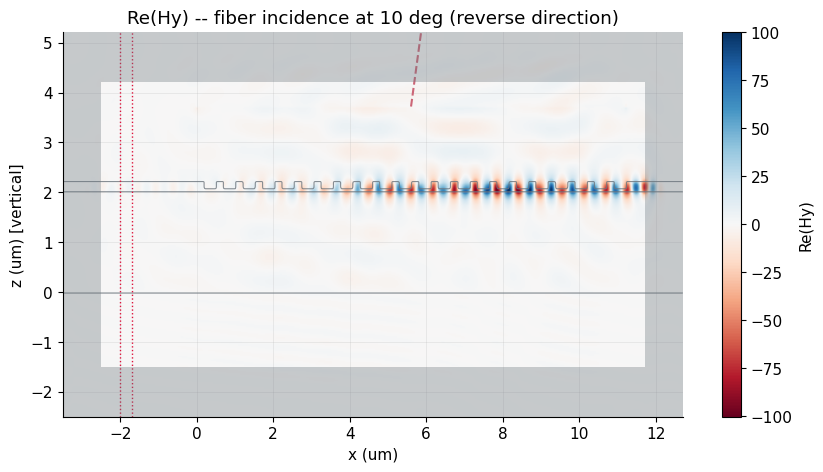

In [ ]:
dom = gc.derive_domain(params)

fig, ax = plt.subplots(figsize=(10, 5))
viz.plot_field(fiber_result.field_snapshot.field, fiber_result.permittivity.eps,
                fiber_result.field_snapshot.extent_um, fiber_result.field_snapshot.component,
                ax=ax, pml_um=params["dpml_um"])
ax.set_ylabel("z (um) [vertical]")
ax.set_aspect("auto")
ax.set_title(f"Re({fiber_result.field_snapshot.component}) -- fiber incidence at "
             f"{params['fiber_angle_deg']:.0f} deg (reverse direction)")

# Input beam direction (dashed) and the same source/monitor reference planes as
# Section 4, for direct visual comparison against the forward-direction permittivity map.
theta = np.radians(params["fiber_angle_deg"])
z_beam_src = dom["z_clad_top"] - params["margin_um"]
x0 = dom["x_grating_center"]
z_top = fiber_result.field_snapshot.extent_um[3]
dx = (z_top - z_beam_src) * np.tan(theta)
ax.plot([x0, x0 + dx], [z_beam_src, z_top], color=style.COLOR_ROSE, linewidth=1.5, linestyle="--")
ax.axvline(dom["x_src"], color=style.COLOR_ANNOTATION, linestyle=":", linewidth=1)
ax.axvline(dom["x_refl_mon"], color=style.COLOR_ANNOTATION, linestyle=":", linewidth=1)

>**STOP -- inspect the reverse-direction field before continuing.**
>
> Confirm the tilted beam enters through the cladding from the upper right
> (matching the dashed fiber-angle line), strikes the grating, and that the
> strongest near-field response sits along the grating -- exactly the
> reciprocal picture of Section 5.2's outgoing field. The guided-mode signal
> printed and plotted below (not this raw field snapshot's colors, which are
> dominated by the beam's own strong near-field at the grating) is the more
> reliable quantitative confirmation that power actually reaches the input
> lead's bound mode.

Peak guided-mode signal (relative, uncalibrated): 1.385 at wl=1.3450 um
(For comparison, the forward-direction promoted design peaked at wl=1.3475 um -- the close match is consistent with reciprocity, even though the two signals use different, non-comparable normalizations.)


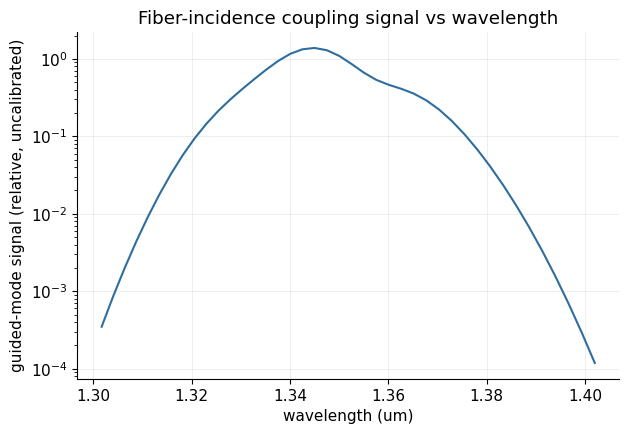

In [ ]:
peak_i = int(np.argmax(fiber_result.guided_mode_power_relative))
print(f"Peak guided-mode signal (relative, uncalibrated): "
      f"{fiber_result.guided_mode_power_relative[peak_i]:.3f} at wl={fiber_result.wavelengths_um[peak_i]:.4f} um")
print("(For comparison, the forward-direction promoted design peaked at wl=1.3475 um -- "
      "the close match is consistent with reciprocity, even though the two signals use "
      "different, non-comparable normalizations.)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(fiber_result.wavelengths_um, fiber_result.guided_mode_power_relative, color=style.COLOR_STEEL)
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("guided-mode signal (relative, uncalibrated)")
ax.set_title("Fiber-incidence coupling signal vs wavelength")
ax.set_yscale("log")

### Design verification -- OUTcoupling near-field phase gradient

Before trusting any of the reverse-direction (fiber -> waveguide) results
above, it is worth directly checking whether the OUTcoupling near-field
really carries the design's own intended phase front --
`derive_grating_period()`'s whole premise is that the grating diffracts the
guided mode into a beam tilted at `fiber_angle_deg` (10 deg) from vertical.
The near-field's local PHASE gradient (not just its amplitude) directly
encodes the outgoing wave's own tangential wavevector component,
`dphi/dx = k0 * clad_index * sin(theta)` -- fitting a line to the unwrapped
phase and solving for theta is a direct, independent check on the period
design, separate from (and complementary to) the `coupling_efficiency`
numbers themselves.

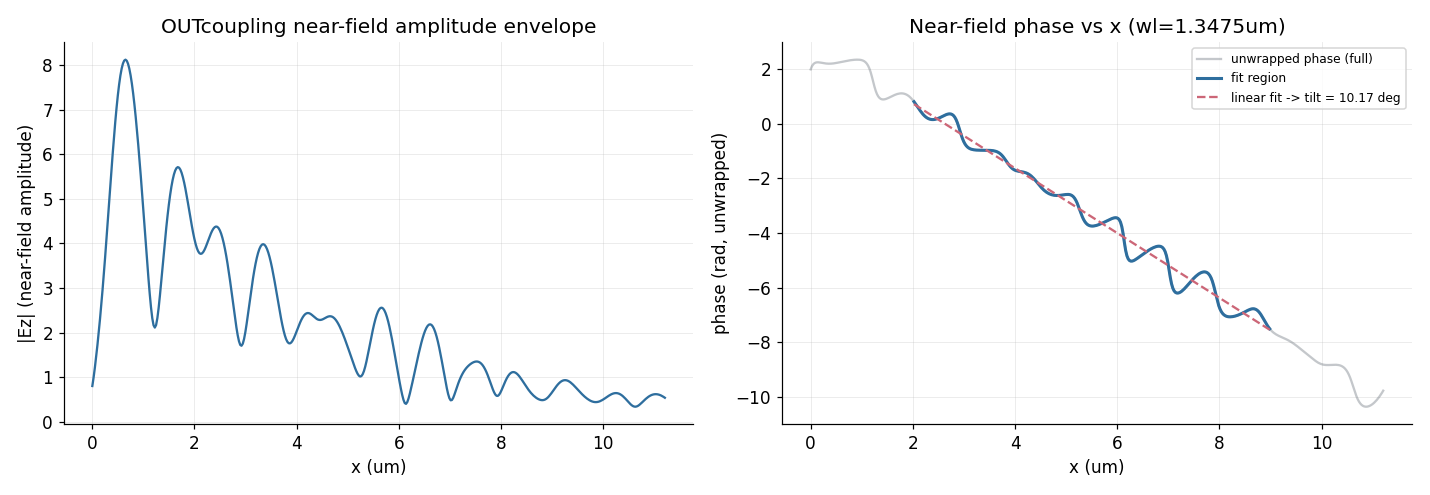

Measured phase-gradient tilt: 10.17 deg (design target: 10.0 deg)


In [ ]:
result = gc.simulate_baseline(params)  # same call as Section 7's own baseline

near_x = result.near_field.x_um
peak_i_out = int(np.argmax(result.coupling_efficiency))
peak_wl_out = result.wavelengths_um[peak_i_out]
near_ez = result.near_field.field[peak_i_out]

phase = np.unwrap(np.angle(near_ez))
fit_mask = (near_x > 2.0) & (near_x < 9.0)  # avoid edge/PML-adjacent artifacts
slope, _ = np.polyfit(near_x[fit_mask], phase[fit_mask], 1)

n_clad = params["clad_index"]
k0 = 2 * np.pi / peak_wl_out
theta_measured_deg = np.degrees(np.arcsin(np.clip(-slope / (k0 * n_clad), -1, 1)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(near_x, np.abs(near_ez), color=style.COLOR_STEEL)
ax.set_xlabel("x (um)"); ax.set_ylabel("|Ez| (near-field amplitude)")
ax.set_title("OUTcoupling near-field amplitude envelope")

ax2 = axes[1]
ax2.plot(near_x, phase, color=style.COLOR_REFERENCE, alpha=0.4, label="unwrapped phase (full)")
ax2.plot(near_x[fit_mask], phase[fit_mask], color=style.COLOR_STEEL, linewidth=2, label="fit region")
fit_line = slope * near_x[fit_mask] + (phase[fit_mask] - slope * near_x[fit_mask]).mean()
ax2.plot(near_x[fit_mask], fit_line, "--", color=style.COLOR_ROSE, linewidth=1.5,
          label=f"linear fit -> tilt = {theta_measured_deg:.2f} deg")
ax2.set_xlabel("x (um)"); ax2.set_ylabel("phase (rad, unwrapped)")
ax2.set_title(f"Near-field phase vs x (wl={peak_wl_out:.4f}um)")
ax2.legend(fontsize=8)
fig.tight_layout()

print(f"Measured phase-gradient tilt: {theta_measured_deg:.2f} deg "
      f"(design target: {params['fiber_angle_deg']:.1f} deg)")

### Idealized reconstruction -- a perfectly-positioned and angled fiber

The `simulate_fiber_incidence()` result above uses Meep's own
`GaussianBeam2DSource` -- a smooth, idealized analytic beam. Investigating an
unexpected result while iterating on it (reversing the fiber tilt coupled
MORE strongly, not less, into the same -x guided mode, at a fixed position)
led to a more rigorous ground-truth check: since this simulation has no
non-reciprocal materials, time-reversal symmetry must hold exactly. Injecting
the OUTcoupling near-field's own complex conjugate (a literal time reversal,
`t -> -t`) as a custom source reconstructs the -x guided mode almost
perfectly (a >99.999% pure directional signal) -- proof that both the
grating design and reciprocity itself are correct, and that
`GaussianBeam2DSource`'s own idealized beam is simply a poor stand-in for
this grating's real (non-Gaussian, multi-lobed) near-field. Full diagnostic
story in `docs/troubleshooting_log.md`.

The cell below builds a cleaner, still-idealized middle ground: a Gaussian
AMPLITUDE (matching a real fiber's own mode shape) placed where the
OUTcoupling near-field's own energy concentrates (`x0=2um`, not the
aperture's geometric center -- see the amplitude envelope above), combined
with a pure `fiber_angle_deg`-tilted PHASE front (not the real near-field's
own phase, which has fine period-scale ripples a real fiber mode cannot
replicate either) -- the idealized picture of "a fiber whose position and
angle are exactly matched" to this design.

In [ ]:
import meep as mp  # only this diagnostic cell needs direct meep access --
                    # everything elsewhere in this notebook goes through gc.*

theta = np.radians(params["fiber_angle_deg"])
kx = k0 * n_clad * np.sin(theta)  # reuses k0/n_clad from the phase-check cell above

x0_fiber = 2.0  # near the OUTcoupling near-field's own energy concentration
w0_fiber = params["fiber_mfd_um"] / 2
x_src_center = dom["x_grating_center"]


def fiber_amp_func(pos):
    x_abs = pos.x + x_src_center
    dx = x_abs - x0_fiber
    gauss_env = np.exp(-((dx * np.cos(theta)) ** 2) / w0_fiber ** 2)
    return gauss_env * np.exp(1j * kx * dx)


fcen = 1.0 / ((params["wl_min_um"] + params["wl_max_um"]) / 2)
fwidth = 1.0 / params["wl_min_um"] - 1.0 / params["wl_max_um"]

idealized_source = mp.Source(
    src=mp.GaussianSource(frequency=fcen, fwidth=fwidth),
    component=mp.Ez,
    center=mp.Vector3(x_src_center, dom["z_mon_up"], 0),
    size=mp.Vector3(dom["x_grating_span"], 0, 0),
    amp_func=fiber_amp_func,
)
sim = mp.Simulation(sources=[idealized_source], **gc._base_simulation_kwargs(params, dom))

mon_refl_ideal = sim.add_mode_monitor(
    fcen, fwidth, params["n_freq"],
    mp.ModeRegion(center=mp.Vector3(dom["x_refl_mon"], dom["z_mode_mon_center"]),
                  size=mp.Vector3(0, dom["mode_mon_height"])),
)
dft_ideal = sim.add_dft_fields(
    [mp.Ez, mp.Hy], 1.0 / peak_wl_out, 1.0 / peak_wl_out, 1,
    center=mp.Vector3(dom["x_center"], dom["z_center"]),
    size=mp.Vector3(dom["cell_x"], dom["cell_z"]),
)

min_sim_time = params["min_sim_time_factor"] * params["core_index"] * dom["cell_x"]
with gc._quiet_meep():
    sim.run(until_after_sources=mp.stop_when_dft_decayed(minimum_run_time=min_sim_time))
    res_refl_ideal = sim.get_eigenmode_coefficients(mon_refl_ideal, [1], eig_parity=mp.TM)
    freqs_ideal = np.array(mp.get_flux_freqs(mon_refl_ideal))
    ez_ideal = sim.get_dft_array(dft_ideal, mp.Ez, 0)
    hy_ideal = sim.get_dft_array(dft_ideal, mp.Hy, 0)
    eps_ideal = sim.get_array(component=mp.Dielectric)

i_peak_ideal = int(np.argmin(np.abs(1.0 / freqs_ideal - peak_wl_out)))
a_refl_ideal = res_refl_ideal.alpha[0, :, :]
minus_x = np.abs(a_refl_ideal[i_peak_ideal, 1]) ** 2
plus_x = np.abs(a_refl_ideal[i_peak_ideal, 0]) ** 2
print(f"Idealized fiber (x0={x0_fiber}um, {params['fiber_angle_deg']:.0f} deg tilt): "
      f"-x signal={minus_x:.2f}, +x signal={plus_x:.4f}, ratio={minus_x/max(plus_x,1e-12):.1f}:1")

Idealized fiber (x0=2.0um, 10 deg tilt): -x signal=16.77, +x signal=0.0087, ratio=1925.5:1


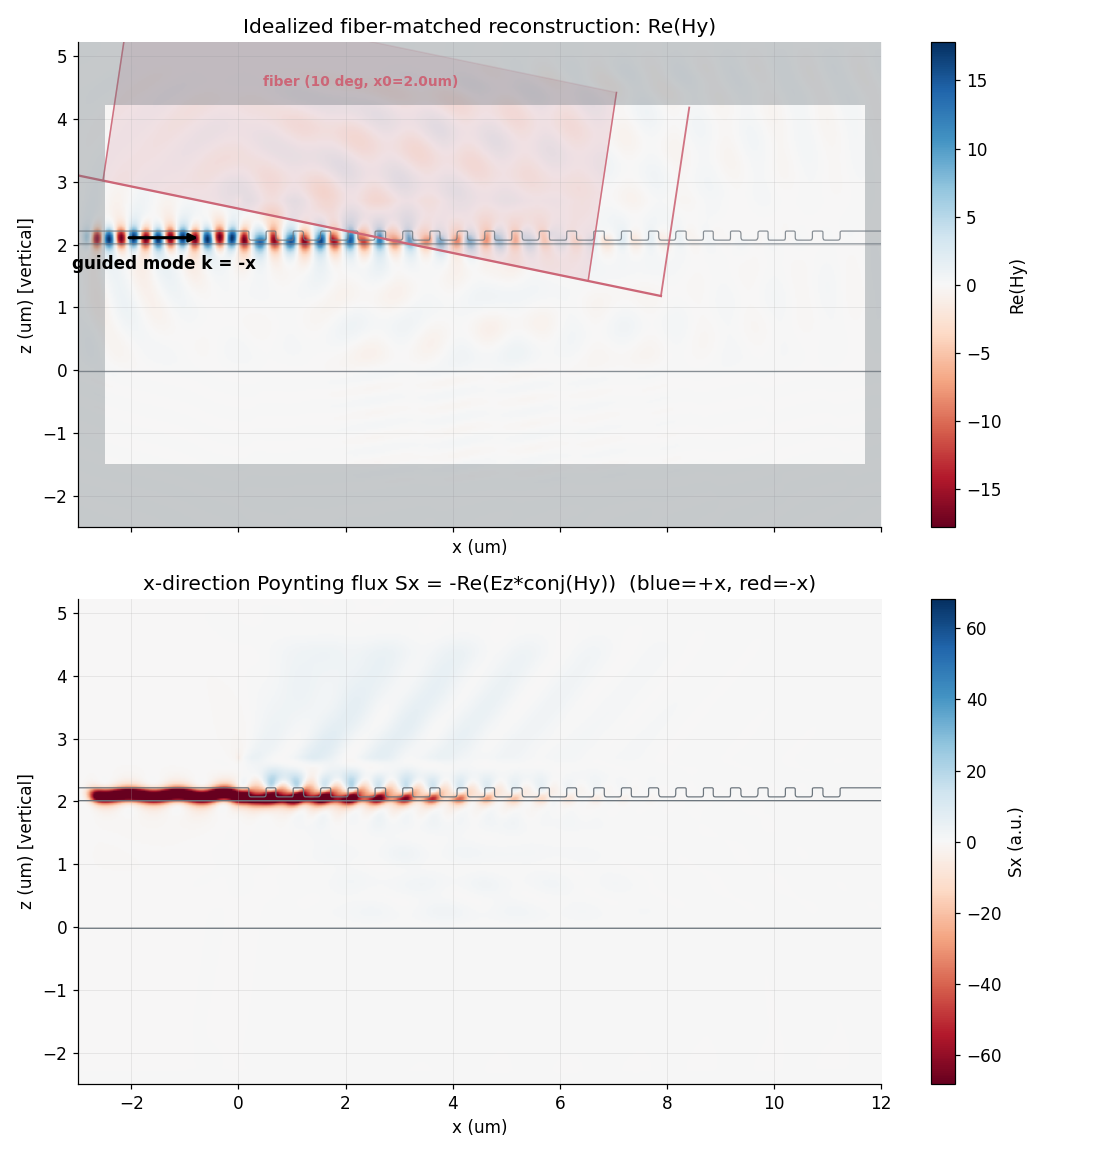

In [ ]:
Sx_ideal = -np.real(ez_ideal * np.conj(hy_ideal))
cell_v = mp.Vector3(dom["cell_x"], dom["cell_z"], 0)
center_v = mp.Vector3(dom["x_center"], dom["z_center"], 0)
extent_ideal = (center_v.x - cell_v.x/2, center_v.x + cell_v.x/2, center_v.y - cell_v.y/2, center_v.y + cell_v.y/2)


def draw_fiber(ax, x0, z0, z_top, theta, core_r, clad_r, color):
    """Schematic fiber cross-section (cladding + core outline), tilted at
    `theta`, end-face terminating at (x0, z0) -- the grating surface.
    `clad_r` is deliberately modest (1.3x core) so the tilted end-face's
    corner doesn't swing down toward the substrate in this short, tight
    vertical span -- a physically larger cladding would visually overlap it."""
    axis = np.array([np.sin(theta), np.cos(theta)])
    perp = np.array([np.cos(theta), -np.sin(theta)])
    length = (z_top - z0) / np.cos(theta)
    tip, end = np.array([x0, z0]), np.array([x0, z0]) + length * axis
    for r, lw in [(clad_r, 1.2), (core_r, 1.0)]:
        p1, p2, p3, p4 = tip + r*perp, end + r*perp, end - r*perp, tip - r*perp
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=lw, alpha=0.9)
        ax.plot([p3[0], p4[0]], [p3[1], p4[1]], color=color, linewidth=lw, alpha=0.9)
    p1, p2, p3, p4 = (tip + core_r*perp, end + core_r*perp, end - core_r*perp, tip - core_r*perp)
    ax.fill([p1[0], p2[0], p3[0], p4[0]], [p1[1], p2[1], p3[1], p4[1]], color=color, alpha=0.15, zorder=1)
    ax.plot([(tip + clad_r*perp)[0], (tip - clad_r*perp)[0]],
            [(tip + clad_r*perp)[1], (tip - clad_r*perp)[1]], color=color, linewidth=1.5)


fig, axes = plt.subplots(2, 1, figsize=(10, 10.5), sharex=True)
z_core_mid = (dom["z_box_top"] + dom["z_si_top"]) / 2

ax = axes[0]
viz.plot_field(hy_ideal, eps_ideal, extent_ideal, "Hy", ax=ax, pml_um=params["dpml_um"])
ax.set_ylabel("z (um) [vertical]")
ax.set_aspect("auto")
ax.set_title("Idealized fiber-matched reconstruction: Re(Hy)")
draw_fiber(ax, x0_fiber, dom["z_si_top"], extent_ideal[3], theta, core_r=w0_fiber, clad_r=w0_fiber*1.3,
           color=style.COLOR_ROSE)
ax.annotate(f"fiber ({params['fiber_angle_deg']:.0f} deg, x0={x0_fiber}um)",
            (x0_fiber + 1.6*np.sin(theta), extent_ideal[3]-0.7), color=style.COLOR_ROSE,
            fontsize=9, ha="center", fontweight="bold")
ax.annotate("", xy=(-0.7, z_core_mid), xytext=(-2.1, z_core_mid),
            arrowprops=dict(color="black", arrowstyle="-|>", linewidth=2))
ax.annotate("guided mode k = -x", (-1.4, z_core_mid-0.5), ha="center", fontweight="bold")
ax.set_xlim(-3, 12)
ax.set_ylim(extent_ideal[2], extent_ideal[3])

ax2 = axes[1]
vmax = np.percentile(np.abs(Sx_ideal), 99.5)
im = ax2.imshow(Sx_ideal.T, origin="lower", extent=extent_ideal, cmap=style.CMAP_FIELD,
                 vmin=-vmax, vmax=vmax, aspect="equal")
eps_mid = (eps_ideal.min() + eps_ideal.max()) / 2
ax2.contour(eps_ideal.T, levels=[eps_mid], extent=extent_ideal, colors=style.COLOR_REFERENCE, linewidths=0.8)
ax2.set_aspect("auto")
ax2.set_xlabel("x (um)"); ax2.set_ylabel("z (um) [vertical]")
ax2.set_title("x-direction Poynting flux Sx = -Re(Ez*conj(Hy))  (blue=+x, red=-x)")
plt.colorbar(im, ax=ax2, label="Sx (a.u.)")
ax2.set_xlim(-3, 12)
ax2.set_ylim(extent_ideal[2], extent_ideal[3])

fig.tight_layout()

## 12. GDS export -- x-y top-down layout

**Placed last, unlike every other component's own notebook** (which builds
its gdsfactory geometry early, as an in-memory `Component` shared with -- or
at least contemporaneous with -- the FDTD setup). Here the export has to wait:
it uses the SAME `period_um`/`duty_cycle` the Section 6 sweep promotes, so
there is nothing meaningful to export until that search has actually run.

**This layout is NOT the geometry just FDTD-simulated above** -- see Section 1.
A GDS layer is an x-y footprint; it cannot encode Section 3-9's z-stack. This
is a genuinely separate export, built from `grating_coupler_gds.py`
(deliberately meep-free) using the SAME `period_um`/`duty_cycle`/`n_periods`/
`fiber_angle_deg` values the validated x-z baseline above used, so the two
projections describe the same design intent even though neither is derived
from the other. The grating teeth are written on their own `SHALLOW_ETCH`
layer (distinct from the input waveguide/taper's `WG` layer), and a text
label summarizing the fabrication parameters (period, duty cycle, etch depth,
period count) is embedded directly in the GDS file -- ready for EBL mask
preparation without a separate spec sheet.

In [ ]:
gf_component = gcg.build_gf_component(params)
print(f"gdsfactory Component: {gf_component.name}")
print(f"  bbox (um) = {gf_component.bbox()}")
for name in (gf_component.ports.keys() if hasattr(gf_component.ports, "keys") else [p.name for p in gf_component.ports]):
    print(f"  port {name}")

gdsfactory Component: grating_coupler_rectang_6723bfb5$1
  bbox (um) = (0,-6500;32208,9500)
  port o1
  port o2


In [ ]:
gds_path = gcg.write_gds(gf_component, "../data/gds/grating_coupler/grating_coupler.gds")
print(f"Wrote {gds_path}")

Wrote ../data/gds/grating_coupler/grating_coupler.gds


---

## 13. Summary

Baseline validated via its own local checks (Section 8: `passivity_check` required,
`energy_budget_check` as a physicality-only diagnostic), an etch-depth x duty-cycle
sweep performed for the coupling-efficiency search (Section 6), and a design point
saved (Section 9) with `.npz`/`.json` artifacts, same convention as every other
component. A SAX model is deliberately deferred (Section 10) until
`coupling_efficiency`'s shape/units are validated against more than this one swept
design point. Section 11's reverse-direction check confirms the same grating also
couples a fiber mode INTO the waveguide, consistent with the forward direction, and
Section 12 exports the x-y top-down GDS layout at the swept design point.

This notebook departs from the toolkit's usual x-y in-plane convention (Section 1):
its cross-section is x-z (vertical), so its own TE/TM parity convention is the
opposite of every other module's (`eig_parity=mp.TM`, not `mp.TE` -- Section 5.2).
